In [23]:
import pandas as pd
import numpy as np
from math import isnan
import multiprocessing as mp
import json
import os
from protocols import utils, functions, graphs
from catomatic.RegressionCatalogue import RegressionBuilder
from statsmodels.stats.proportion import proportions_ztest



%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# the path to the CRyPTIC v3.1.0 data tables (including the DST_MEASUREMENTS_+.pkl which has DST for the validation samples appended)
cryptic_tables_path = 'data/cryptic-tables-v3.3.0/'

#read in genes relevant to each drug
with open('data/drug_to_genes.json', 'r') as f:
    drug_genes = json.load(f)

# whether to run the processes which take a long time
run_long_processes = False

# number of cores
n_cores = 10

who_drugs = list(pd.read_csv('data/who2_drugs.csv').drug)

In [25]:
who_drugs

['INH',
 'RIF',
 'PZA',
 'EMB',
 'BDQ',
 'LZD',
 'MXF',
 'LEV',
 'CFZ',
 'DLM',
 'AMI',
 'STM',
 'ETH',
 'KAN',
 'CAP']

In [ ]:
def process_performance(args):
    #apply the specified catalogues to the specified dataset (training, validation, or all)
    #parallelises across number of cores specified above
    
    drug, genes, catalogues, validation, FRS, dataset = args
    results = []

    if drug in who_drugs:
        
        mutations = functions.prep_mutations(
            'data/mutations-v3.3.0/', 
            genes, 
            version='v3.3.0', 
            mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
            var_path=cryptic_tables_path+'VARIANTS.parquet',
            train=False
        )

        if dataset != 'all':
            phenotypes = functions.prep_phenotypes(
                drug,
                cryptic_tables_path+'DST_MEASUREMENTS.csv.gz',
                cryptic_tables_path+'GENOMES.parquet',
                cryptic_tables_path+'WGS_SAMPLES.parquet',
                version='v3.3.0',
                validation= validation
            )
        else:
            train_phenotypes = functions.prep_phenotypes(
            drug,
            cryptic_tables_path+'DST_MEASUREMENTS.csv.gz',
            cryptic_tables_path+'GENOMES.parquet',
            cryptic_tables_path+'WGS_SAMPLES.parquet',
            version='v3.3.0',
            validation= False
            )

            val_phenotypes = functions.prep_phenotypes(
            drug,
            cryptic_tables_path+'DST_MEASUREMENTS.csv.gz',
            cryptic_tables_path+'GENOMES.parquet',
            cryptic_tables_path+'WGS_SAMPLES.parquet',
            version='v3.3.0',
            validation= True
            )
            phenotypes = pd.concat([train_phenotypes, val_phenotypes])

        phenotypes.set_index('UNIQUEID', inplace=True)
        mutations.set_index('UNIQUEID', inplace=True)
        all_data = phenotypes.join(mutations[mutations.FRS >= FRS], how='left')
        all_data.reset_index(inplace=True)

        if len(all_data)>0:

            for cat_name in catalogues:

                cm, cov, sens, spec, sens2, spec2 = utils.piezo_predict(iso_df=all_data, drug=drug, catalogue_file=catalogues[cat_name])

                TP = cm[0, 0]
                FN = cm[0, 1]
                TN = cm[1, 1]
                FP = cm[1, 0]
                UP = cm[0, 2]
                UN = cm[1, 2]

                results.append({
                    'DRUG': drug,
                    'catalogue': cat_name,
                    'SENSITIVITY': sens,
                    'SPECIFICITY': spec,
                    'COVERAGE': cov,
                    'SENSITIVITY2': sens2,
                    'SPECIFICITY2': spec2,
                    'TP': TP,
                    'FN': FN,
                    'TN': TN,
                    'FP': FP,
                    'UP': UP,
                    'UN': UN
                })

    return results

def parallel_performance_evaluation(drug_genes, catalogues,  validation, frs, dataset=None):
    tasks = [(drug, data['genes'], catalogues, validation, frs, dataset) for drug, data in drug_genes.items()]
    
    # Works on Mac/Linux
    ctx = mp.get_context("fork") 
    
    # Don't use more workers than tasks
    num_workers = min(n_cores, len(tasks))  

    # Run in parallel
    with ctx.Pool(num_workers) as pool:
        all_results = list(pool.imap(process_performance, tasks))
    
    results_df = pd.DataFrame([item for sublist in all_results for item in sublist])

    return results_df



In [124]:
def generate_pvals(df, comparisons):
    #caluclate pvalues (proportions Z-test) for specifieid comparitors.
    # e.g [('catomatic_v3.3.0', 'WHOv1'), ('catomatic_v3.3.0', 'WHOv2'), ('WHOv1', 'WHOv2')]

    assert comparisons is not None, 'comparison keys must be spcified'

    metric_funcs = {
        'sens_p_value': lambda r: (r['TP'], r['TP'] + r['FN']),
        'spec_p_value': lambda r: (r['TN'], r['TN'] + r['FP']),
        'dpr_p_value': lambda r: (r['TP'] + r['TN'] + r['FP'] + r['FN'], 
                                r['TP'] + r['TN'] + r['FP'] + r['FN'] + r['UP'] + r['UN']),
        'sens2_p_value': lambda r: (r['TP'], r['TP'] + r['FN'] + r['UP']),
        'spec2_p_value': lambda r: (r['TN'] + r['UN'], r['TN'] + r['FP'] + r['UN'])
    }
    results = []
    # Loop over each drug and comparison
    for drug in df['DRUG'].unique():
        df_drug = df[df['DRUG'] == drug]
        for cat1, cat2 in comparisons:
            row = {'DRUG': drug, 'Comparison': f'{cat1} > {cat2}'}
            g1 = df_drug[df_drug['catalogue'] == cat1].iloc[0]
            g2 = df_drug[df_drug['catalogue'] == cat2].iloc[0]
            for col_name, fn in metric_funcs.items():
                c1, n1 = fn(g1)
                c2, n2 = fn(g2)
                stat, pval = proportions_ztest([c1, c2], [n1, n2], alternative='larger')
                row[col_name] = pval
            results.append(row)

    return pd.DataFrame(results)


### WHOv1 vs WHOv2 applied to our training set (FRS 0.75)

In [ ]:
#performance on whov1 for whov1 and whov2, at FRS 0.75 (even playing field)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
    }

    results_who_train = parallel_performance_evaluation(drug_genes, catalogues, validation=False, frs=0.75)
    results_who_train.to_csv('results/performance/whov1_whov2_training.csv')
results_who_train = pd.read_csv('results/performance/whov1_whov2_training.csv')
results_who_train[:6]

In [ ]:
pvals = generate_pvals(results_who_train, comparisons=[('WHOv1', 'WHOv2')])
pvals.to_csv('results/performance/p_vals_whov1_whov2_training.csv')
pvals[(pvals.sens_p_value<0.05)|(pvals.spec_p_value<0.05)|(pvals.dpr_p_value<0.05)]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
1,BDQ,WHOv1 > WHOv2,1.000000,5.149690e-33,9.486810e-84,1.000000,4.096721e-32
3,CFZ,WHOv1 > WHOv2,1.000000,1.472032e-33,1.686926e-112,1.000000,1.552410e-32
5,EMB,WHOv1 > WHOv2,0.000088,9.996024e-01,1.000000e+00,0.000115,9.462494e-01
7,INH,WHOv1 > WHOv2,0.987775,1.607677e-01,7.038151e-03,0.975329,1.764136e-01
8,KAN,WHOv1 > WHOv2,0.524143,4.591016e-01,5.112158e-03,0.500000,5.000000e-01
13,RIF,WHOv1 > WHOv2,0.535928,4.707884e-01,4.857772e-02,0.523805,4.881529e-01


### WHOv1 vs WHOv2 applied to our validation set (FRS 0.75)

In [170]:
#performance on whov1 for whov1 and whov2, at FRS 0.75 (even playing field)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
    }

    results_who_val = parallel_performance_evaluation(drug_genes, catalogues, validation=True, frs=0.75)
    results_who_val.to_csv('results/performance/whov1_whov2_validation.csv')
results_who_val = pd.read_csv('results/performance/whov1_whov2_validation.csv')
results_who_val[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,0,AMI,WHOv1,0.837178,0.987407,0.944923,0.820479,0.988146,617,120,6743,86,15,426
1,1,AMI,WHOv2,0.832659,0.987449,0.948295,0.820479,0.988146,617,124,6766,86,11,403
2,2,BDQ,WHOv1,0.000000,1.000000,1.000000,0.000000,1.000000,0,834,3828,0,0,0
3,3,BDQ,WHOv2,0.566216,0.988276,0.963749,0.502398,0.988506,419,321,3709,44,94,75
4,4,CAP,WHOv1,0.742857,0.983305,0.962847,0.699160,0.983886,416,144,5183,88,35,190
5,5,CAP,WHOv2,0.754750,0.982896,0.964498,0.734454,0.983520,437,142,5172,90,16,199


In [ ]:
pvals = generate_pvals(results_who_val, comparisons=[('WHOv1', 'WHOv2')])
pvals.to_csv('results/performance/p_vals_whov1_whov2_validation.csv')
pvals[(pvals.sens_p_value<0.05)|(pvals.spec_p_value<0.05)|(pvals.dpr_p_value<0.05)]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
1,BDQ,WHOv1 > WHOv2,1.000000,5.149690e-33,9.486810e-84,1.000000,4.096721e-32
3,CFZ,WHOv1 > WHOv2,1.000000,1.472032e-33,1.686926e-112,1.000000,1.552410e-32
5,EMB,WHOv1 > WHOv2,0.000088,9.996024e-01,1.000000e+00,0.000115,9.462494e-01
7,INH,WHOv1 > WHOv2,0.987775,1.607677e-01,7.038151e-03,0.975329,1.764136e-01
8,KAN,WHOv1 > WHOv2,0.524143,4.591016e-01,5.112158e-03,0.500000,5.000000e-01
13,RIF,WHOv1 > WHOv2,0.535928,4.707884e-01,4.857772e-02,0.523805,4.881529e-01


### WHOv1 vs WHOv2 vs catomatic on training set (FRS 0.1)

In [131]:
#performance on training set (ie cryptic-v1.0)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
        'catomatic_v3.3.0': "catalogues/catomatic_v3.3.0.csv",
    }

    results_train = parallel_performance_evaluation(drug_genes, catalogues, validation=False, frs=0.1)
    results_train.to_csv('results/performance/whov1_whov2_cat1_training.csv')
results_train = pd.read_csv('results/performance/whov1_whov2_cat1_training.csv')
results_train[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,0,AMI,WHOv1,0.849007,0.983143,0.922188,0.821795,0.984519,1282,228,16797,288,50,1519
1,1,AMI,WHOv2,0.841760,0.983226,0.926999,0.821795,0.984519,1282,241,16881,288,37,1435
2,2,AMI,catomatic_v3.3.0,0.849802,0.982971,0.922734,0.826923,0.984358,1290,228,16797,291,42,1516
3,3,BDQ,WHOv1,0.000000,1.000000,1.000000,0.000000,1.000000,0,119,12298,0,0,0
4,4,BDQ,WHOv2,0.504950,0.983612,0.966417,0.428571,0.984144,51,50,11704,195,18,399
5,5,BDQ,catomatic_v3.3.0,0.541284,0.990604,0.960216,0.495798,0.990974,59,50,11703,111,10,484


In [140]:
pvals_train = generate_pvals(results_train, comparisons=[('WHOv1', 'WHOv2'), ('WHOv1', 'catomatic_v3.3.0'), ('WHOv2', 'catomatic_v3.3.0')])
pvals_train.to_csv('results/performance/p_vals_whov1_whov2_cat1_training.csv')
pvals_train[(pvals_train.sens_p_value<0.05)|(pvals_train.spec_p_value<0.05)|(pvals_train.dpr_p_value<0.05)][:6]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
3,BDQ,WHOv1 > WHOv2,1.000000,2.117002e-46,1.546335e-94,1.000000,5.886830e-45
4,BDQ,WHOv1 > catomatic_v3.3.0,1.000000,2.280373e-27,6.323284e-112,1.000000,2.295311e-26
5,BDQ,WHOv2 > catomatic_v3.3.0,0.700814,9.999991e-01,4.671466e-03,0.850854,9.999993e-01
7,CAP,WHOv1 > catomatic_v3.3.0,0.953002,4.825370e-01,3.608775e-32,0.913420,6.619028e-01
8,CAP,WHOv2 > catomatic_v3.3.0,0.942086,5.463256e-01,2.687130e-29,0.860717,7.106116e-01
9,CFZ,WHOv1 > WHOv2,1.000000,2.112512e-47,3.382814e-122,1.000000,8.428562e-46


### WHOv1 vs WHOv2 vs catomatic on validation set (FRS 0.1)

In [134]:
#performance on validation set (ie > cryptic-v1.0)
if run_long_processes:

    catalogues = {
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'WHOv2': 'catalogues/whov2/NC_000962.3_WHO-UCN-TB-2023.5_v2.0_GARC1_RFUS.csv',
        'catomatic_v3.3.0': "catalogues/catomatic_v3.3.0.csv",
    }

    results_val = parallel_performance_evaluation(drug_genes, catalogues, validation=True, frs=0.1)
    results_val.to_csv('results/performance/whov1_whov2_cat1_validation.csv')
results_val = pd.read_csv('results/performance/whov1_whov2_cat1_validation.csv')
results_val[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,0,AMI,WHOv1,0.873813,0.986281,0.938679,0.856383,0.987181,644,93,6686,93,15,476
1,1,AMI,WHOv2,0.869096,0.986332,0.942300,0.856383,0.987181,644,97,6711,93,11,451
2,2,AMI,catomatic_v3.3.0,0.873813,0.986136,0.938804,0.856383,0.987043,644,93,6686,94,15,475
3,3,BDQ,WHOv1,0.000000,1.000000,1.000000,0.000000,1.000000,0,834,3828,0,0,0
4,4,BDQ,WHOv2,0.807314,0.982583,0.953024,0.688249,0.983020,574,137,3667,65,123,96
5,5,BDQ,catomatic_v3.3.0,0.719262,0.988143,0.900686,0.420863,0.988506,351,137,3667,44,346,117


In [144]:
pvals_val = generate_pvals(results_val, comparisons=[('WHOv1', 'WHOv2'), ('WHOv1', 'catomatic_v3.3.0'), ('WHOv2', 'catomatic_v3.3.0')])
pvals_val.to_csv('results/performance/p_vals_whov1_whov2_cat1_validation.csv')
pvals_val[(pvals_val.Comparison=='WHOv1 > catomatic_v3.3.0')]

,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
1,AMI,WHOv1 > catomatic_v3.3.0,0.500000,4.710538e-01,5.131439e-01,5.000000e-01,4.706631e-01
4,BDQ,WHOv1 > catomatic_v3.3.0,1.000000,7.056048e-12,2.908599e-108,1.000000e+00,1.441825e-11
7,CAP,WHOv1 > catomatic_v3.3.0,0.512274,4.431137e-01,1.377958e-05,5.522238e-01,5.000000e-01
10,CFZ,WHOv1 > catomatic_v3.3.0,0.999999,1.618210e-07,2.170752e-38,9.999970e-01,2.745442e-07
13,DLM,WHOv1 > catomatic_v3.3.0,0.958812,2.945959e-02,0.000000e+00,9.234791e-01,7.861639e-02
16,EMB,WHOv1 > catomatic_v3.3.0,0.027929,9.999959e-01,1.000000e+00,1.590201e-01,7.105235e-01
19,ETH,WHOv1 > catomatic_v3.3.0,0.456979,1.383097e-12,1.000000e+00,4.030922e-01,1.962350e-15
22,INH,WHOv1 > catomatic_v3.3.0,0.973106,4.904240e-01,9.999999e-01,9.986826e-01,4.235521e-01
25,KAN,WHOv1 > catomatic_v3.3.0,0.632377,1.418381e-50,9.998287e-01,6.480830e-01,1.154246e-51
28,LEV,WHOv1 > catomatic_v3.3.0,0.452959,9.147794e-01,5.000000e-01,4.301769e-01,9.142653e-01


### WHOv1 (train) vs WHOv1 (val) & WHOv2 (train) vs WHOv2 (val)

Already generated results, just in different tables, so can combine and calculate p values 

In [177]:
#generate p values for WHOv1 on training set vs WHOv1 on validation set (and the same for whov2)
catalogues = ['WHOv1', 'WHOv2']

metric_funcs = {
    'sens_p_value': lambda r: (r['TP'], r['TP'] + r['FN']),
    'spec_p_value': lambda r: (r['TN'], r['TN'] + r['FP']),
    'dpr_p_value': lambda r: (r['TP'] + r['TN'] + r['FP'] + r['FN'], 
                              r['TP'] + r['TN'] + r['FP'] + r['FN'] + r['UP'] + r['UN']),
    'sens2_p_value': lambda r: (r['TP'], r['TP'] + r['FN'] + r['UP']),
    'spec2_p_value': lambda r: (r['TN'] + r['UN'], r['TN'] + r['FP'] + r['UN'])
}

results = []

for drug in results_train['DRUG'].unique():
    for cat in catalogues:
        g_train = results_train[(results_train['DRUG'] == drug) & (results_train['catalogue'] == cat)].iloc[0]
        g_valid = results_val[(results_val['DRUG'] == drug) & (results_val['catalogue'] == cat)].iloc[0]
        row = {'DRUG': drug, 'Comparison': f'{cat} (train > valid)'}
        for col_name, fn in metric_funcs.items():
            c1, n1 = fn(g_train)
            c2, n2 = fn(g_valid)
            stat, pval = proportions_ztest([c1, c2], [n1, n2], alternative='larger')
            row[col_name] = pval
        results.append(row)

df_train_vs_valid_pvals = pd.DataFrame(results)
df_train_vs_valid_pvals[df_train_vs_valid_pvals.sens_p_value<0.05]

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
10,EMB,WHOv1 (train > valid),0.000018,2.496106e-117,4.890564e-42,0.000036,7.236068e-82
11,EMB,WHOv2 (train > valid),0.000068,9.039095e-121,1.559179e-66,0.006368,3.387544e-84
12,ETH,WHOv1 (train > valid),0.005844,9.977578e-01,6.186983e-03,0.157120,9.993169e-01
13,ETH,WHOv2 (train > valid),0.007888,9.769607e-01,4.510868e-02,0.340317,9.890845e-01
26,RIF,WHOv1 (train > valid),0.016592,5.128985e-02,1.000000e+00,0.013335,3.917437e-02
27,RIF,WHOv2 (train > valid),0.015090,5.258296e-02,9.999999e-01,0.018662,4.079696e-02


### WHOv1 without rules vs WHOv1 with rules vs catomaticv1

In [196]:
cat = pd.read_csv('catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv')

w_garc_path = 'catalogues/whov1/WHO-UCN-GTB-PCI-2021.7-eng_w_GARC.xlsx'
#flag mutations that had expert rules applied to WHOv1
if not os.path.exists(w_garc_path):
    utils.generate_garc_mutations('catalogues/whov1/WHO-UCN-GTB-PCI-2021.7-eng.xlsx', 'data/NC_000962.3.gbk').to_excel(w_garc_path)

who_original = pd.read_excel(w_garc_path)

filtered = who_original[~who_original['Additional grading criteria'].isna()]

prediction_map = {
    'Assoc w R': 'R',
    'Assoc w R - Interim': 'R',
    'Uncertain significance': 'U',
    'Not assoc w R': 'S',
    'Not assoc w R - Interim': 'S'
}
filtered['PREDICTION'] = filtered['INITIAL CONFIDENCE GRADING'].map(prediction_map)
mapping = dict(zip(filtered['GARC_MUTATION'], filtered['PREDICTION']))
normalized_order = {
    '&'.join(sorted(key.split('&'))): val
    for key, val in mapping.items()
}
def normalize_order(mutation_str):
    return '&'.join(sorted(mutation_str.split('&')))

cat_no_rules = cat[(~cat['MUTATION'].str.contains('indel'))]
mask = cat_no_rules["MUTATION"].str.contains(r"[*?=]", regex=True)
cat_no_rules.loc[mask & (cat_no_rules["PREDICTION"] == "R"), "PREDICTION"] = "U"

cat_no_rules['PREDICTION'] = cat_no_rules.apply(
    lambda row: normalized_order.get(normalize_order(row['MUTATION']), row['PREDICTION']),
    axis=1
)
cat_no_rules['PREDICTION'] = cat_no_rules['PREDICTION'].fillna('U')
cat_no_rules.to_csv('./catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS_no_rules.csv')

/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_487/1780233048.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['PREDICTION'] = filtered['INITIAL CONFIDENCE GRADING'].map(prediction_map)
/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_487/1780233048.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cat_no_rules['PREDICTION'] = cat_no_rules.apply(
/var/folders/s5/pshvb2093574r5hqnwcy6klw0000gn/T/ipykernel_487/1780233048.py:36: SettingWithCopyWarning: 
A value is trying t

In [ ]:
if run_long_processes:

    catalogues = {
        'WHOv1_no_rules': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS_no_rules.csv',
        'WHOv1': 'catalogues/whov1/NC_000962.3_WHO-UCN-GTB-PCI-2021.7_v1.2_GARC1_RUS.csv',
        'catomatic_v3.3.0': "catalogues/catomatic_v3.3.0.csv",
    }

    results_val_no_rules = parallel_performance_evaluation(drug_genes, catalogues, validation=True, frs=0.1)
    results_val_no_rules.to_csv('results/performance/whov1_no_rules_whov1_cat1_validation.csv')
results_val_no_rules[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
8,8,CAP,catomatic_v3.3.0,0.793478,0.980912,0.938904,0.736134,0.982055,438,114,5036,98,43,327
6,6,CAP,WHOv1_no_rules,0.790441,0.981856,0.954425,0.722689,0.982604,430,114,5141,95,51,225
7,7,CAP,WHOv1,0.792727,0.981294,0.955911,0.732773,0.982055,436,114,5141,98,45,222
26,26,KAN,catomatic_v3.3.0,0.866599,0.928624,0.954467,0.856137,0.932208,851,131,6271,482,12,357
24,24,KAN,WHOv1_no_rules,0.860656,0.981963,0.941387,0.845070,0.983122,840,136,6533,120,18,457
25,25,KAN,WHOv1,0.861366,0.981963,0.942004,0.850101,0.983122,845,136,6533,120,13,457


In [205]:
#generate p values for whov1 vs whov2 vs catomatic
pvals_val_no_rules = generate_pvals(results_val_no_rules, comparisons=[('catomatic_v3.3.0', 'WHOv1_no_rules'), ('catomatic_v3.3.0', 'WHOv1'), ('WHOv1', 'WHOv1_no_rules')])
pvals_val.to_csv('results/performance/p_vals_whov1_whov1_no_rules_cat1_validation.csv')
pvals_val_no_rules[(pvals_val_no_rules.Comparison=='WHOv1 > WHOv1_no_rules')&(pvals_val_no_rules.sens_p_value<0.05)]

/Users/dylanadlard/miniforge3/envs/cryptic-catalogues-25/lib/python3.13/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


,DRUG,Comparison,sens_p_value,spec_p_value,dpr_p_value,sens2_p_value,spec2_p_value
8,PZA,WHOv1 > WHOv1_no_rules,0.047981,0.999996,1.232913e-26,4.121665e-19,0.999998
38,ETH,WHOv1 > WHOv1_no_rules,0.035811,1.000000,1.275917e-13,2.399619e-15,1.000000


### catomatic vs catomatic_all_samples applied to all samples

In [148]:
#performance of catalogue trained on samples, applied to all samples (+catomatic trained on training samples applied to all data)
if run_long_processes:

    catalogues = {
        'catomatic_v3.3.0': "catalogues/catomatic_v3.3.0.csv",
        'catomatic_v3.3.0_all_samples': "catalogues/catomatic_v3.3.0_all_samples.csv",
    }

    results_all = parallel_performance_evaluation(drug_genes, catalogues, validation=False,  dataset='all', frs=0.1)
    results_all.to_csv('results/performance/cat_all_samples.csv')
results_all[:6]

,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
0,AMI,catomatic_v3.3.0,0.857650,0.983870,0.927301,0.836505,0.985112,1934,321,23483,385,57,1991
1,AMI,catomatic_v3.3.0_all_samples,0.857650,0.983952,0.927230,0.836505,0.985189,1934,321,23483,383,57,1993
2,BDQ,catomatic_v3.3.0,0.686767,0.990016,0.943966,0.430220,0.990388,410,187,15370,155,356,601
3,BDQ,catomatic_v3.3.0_all_samples,0.805525,0.984133,0.953393,0.764953,0.984869,729,176,15134,244,48,748
4,CAP,catomatic_v3.3.0,0.822690,0.977730,0.928442,0.780787,0.979368,1211,261,14532,331,79,1180
5,CAP,catomatic_v3.3.0_all_samples,0.824950,0.977598,0.929635,0.793037,0.979243,1230,261,14532,333,60,1178


## Plot Results


### WHOv1 (applied to training set) vs published WHOv1 vs WHOv2 (applied to training set) vs published WHOv2

In [155]:
#read in published WHO results
who_results = pd.read_csv('data/WHO2-Annex1-table.csv')
who_results = who_results.iloc[::-1]
who_results = who_results[who_results.FRS==0.75]

#read in WHO results applied to our training set
who_train = pd.read_csv('results/performance/whov1_whov2_training.csv')
who_train.sort_values(['DRUG','catalogue'], inplace=True)


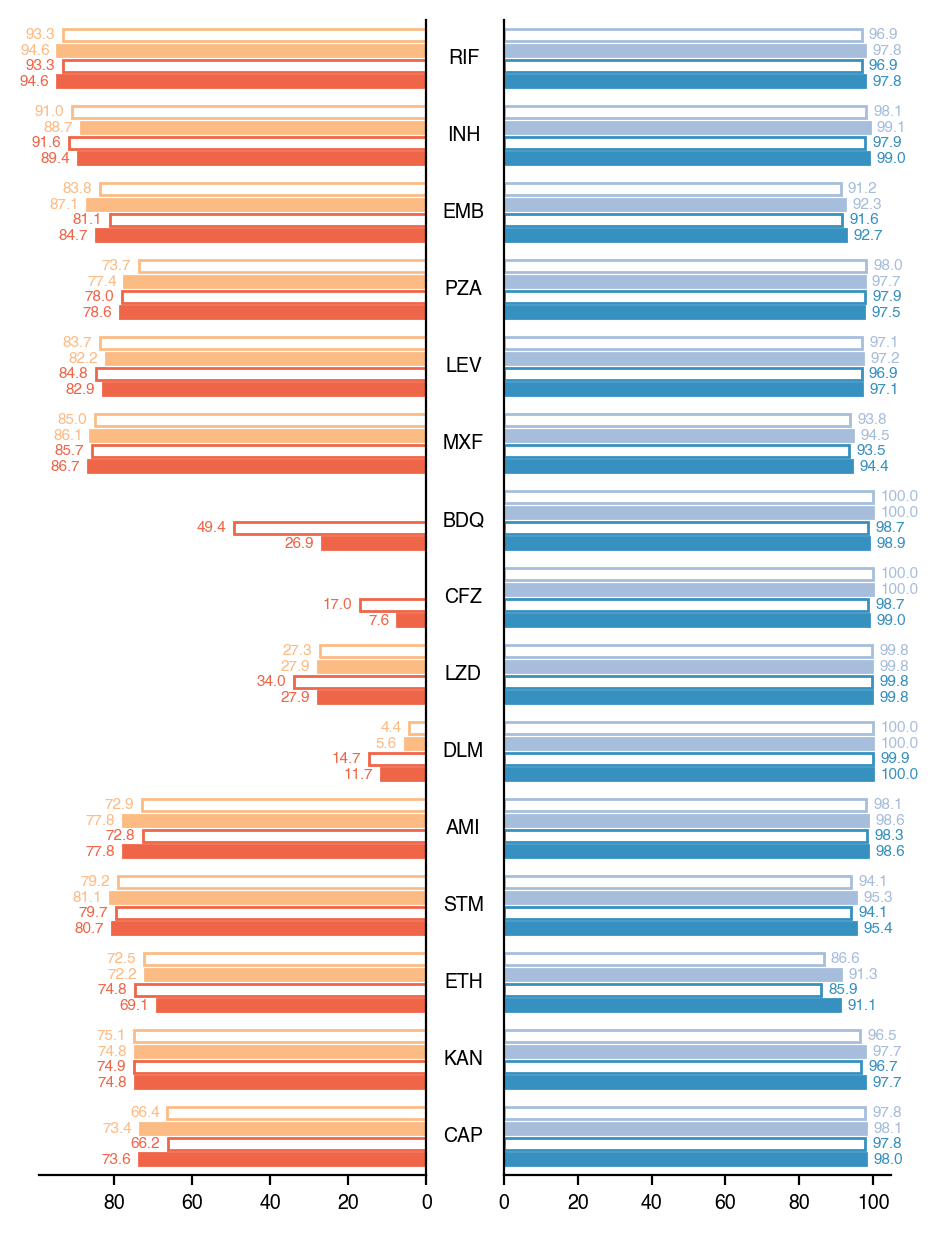

In [167]:
#training set (cryptic-v1.0.0) - BINARY
graphs.plot_bar_who(who_train, who_results,'figs/performance/bar-training-who1-who2.pdf', who_drugs, show_graph=True)

### WHOv1 (applied to validation set) vs published WHOv1 vs WHOv2 (applied to validation set) vs published WHOv2

In [171]:
#read in WHO results applied to our validation set
who_val = pd.read_csv('results/performance/whov1_whov2_validation.csv')
who_val.sort_values(['DRUG','catalogue'], inplace=True)

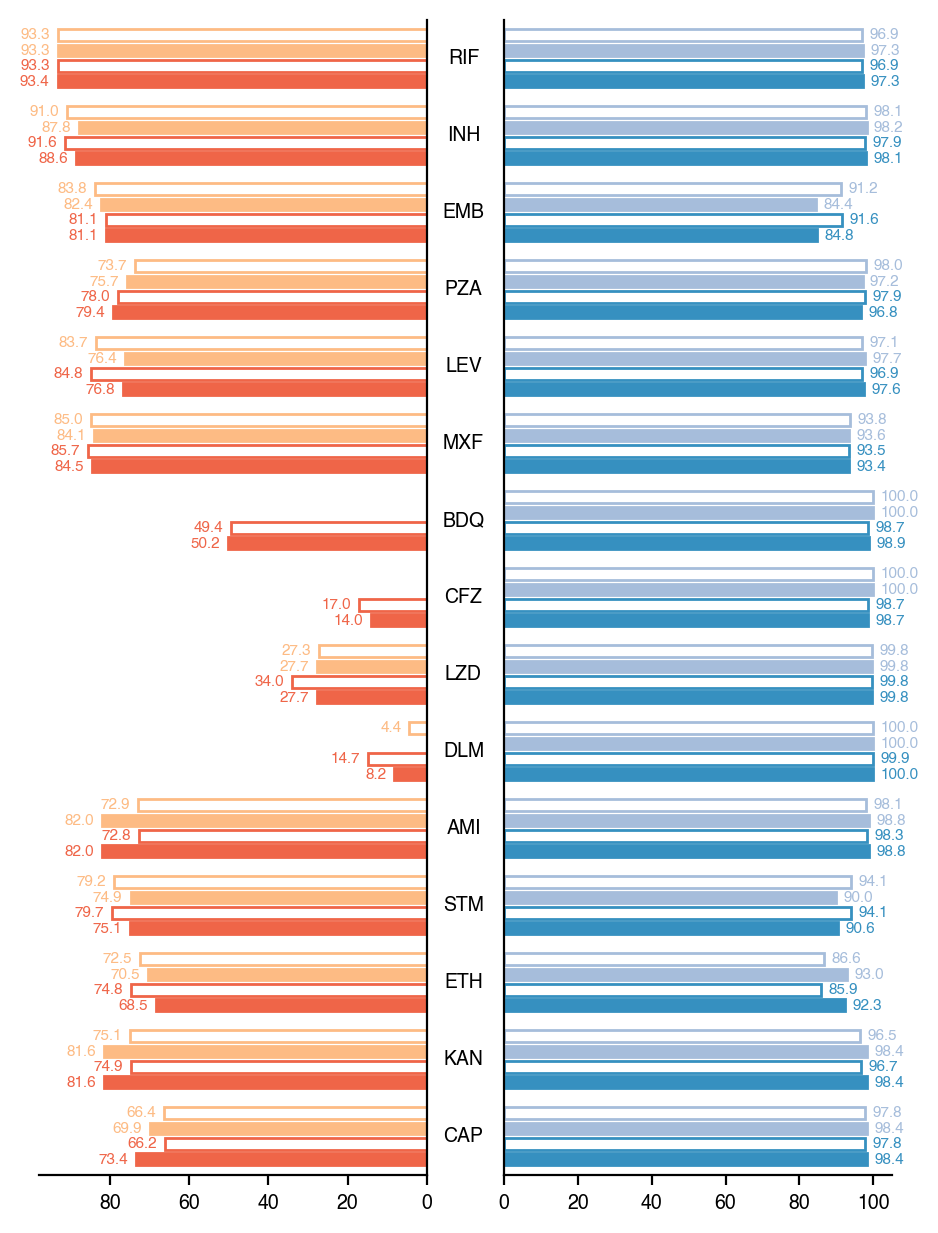

In [172]:
graphs.plot_bar_who(who_val, who_results,'figs/performance/bar-validation-who1-who2.pdf', who_drugs, show_graph=True)

### WHOv1 VS WHOv2 vs catomatic on training set (ternary)

In [181]:
results_training = pd.read_csv('results/performance/whov1_whov2_cat1_training.csv')
results_training.DRUG = results_training.DRUG.astype('category')
results_training.DRUG = results_training.DRUG.cat.set_categories(who_drugs)
results_training.sort_values(['DRUG','catalogue'], inplace=True)
results_training = results_training.iloc[::-1]
results_training = results_training[results_training.DRUG.isin(who_results.drug.values)]
results_training[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
8,8,CAP,catomatic_v3.3.0,0.840217,0.976051,0.922950,0.808577,0.977981,773,147,9496,233,36,853
7,7,CAP,WHOv2,0.812500,0.975798,0.957792,0.788703,0.976847,754,174,9878,245,28,459
6,6,CAP,WHOv1,0.810606,0.976146,0.959352,0.783473,0.977131,749,175,9903,242,32,437
26,26,KAN,catomatic_v3.3.0,0.835616,0.929473,0.953940,0.831969,0.933037,1525,300,15090,1145,8,864
25,25,KAN,WHOv2,0.805028,0.974120,0.933393,0.786143,0.975964,1441,349,15470,411,43,1218
24,24,KAN,WHOv1,0.804578,0.974319,0.939943,0.786143,0.975964,1441,350,15593,411,42,1095


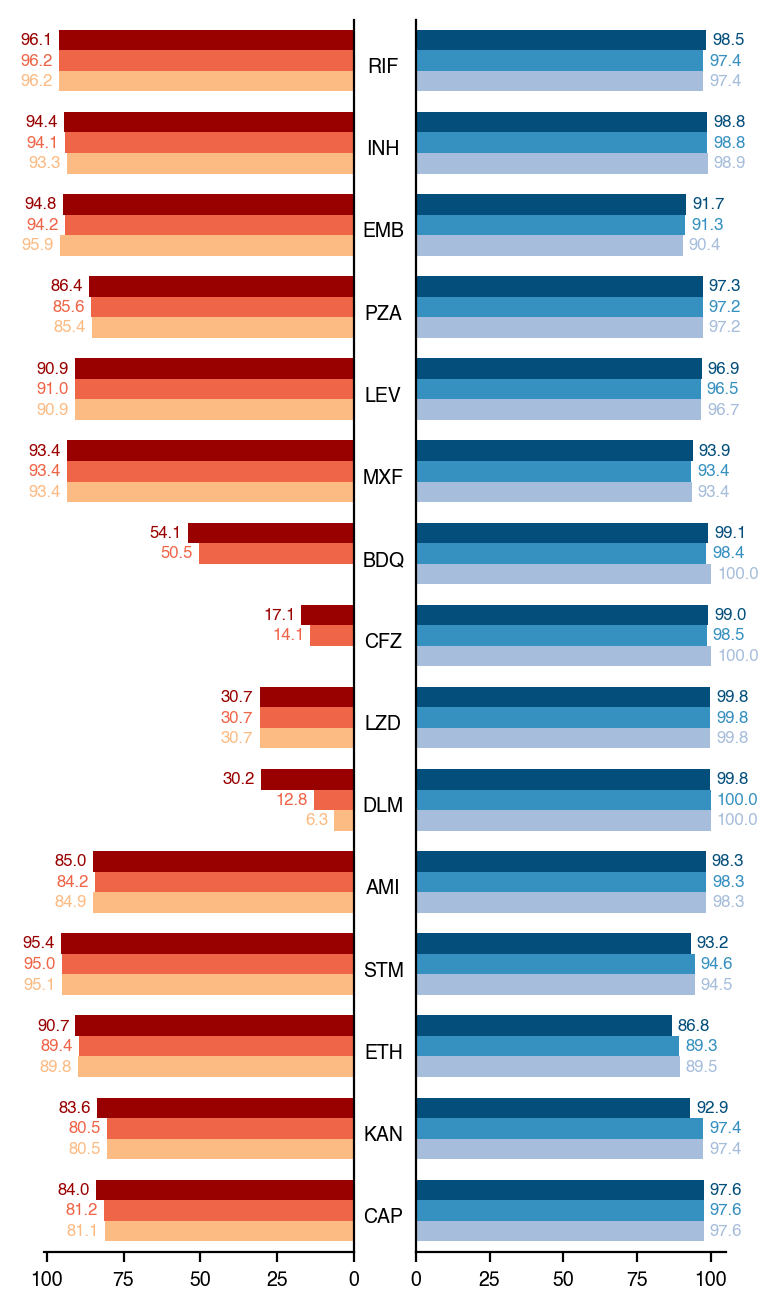

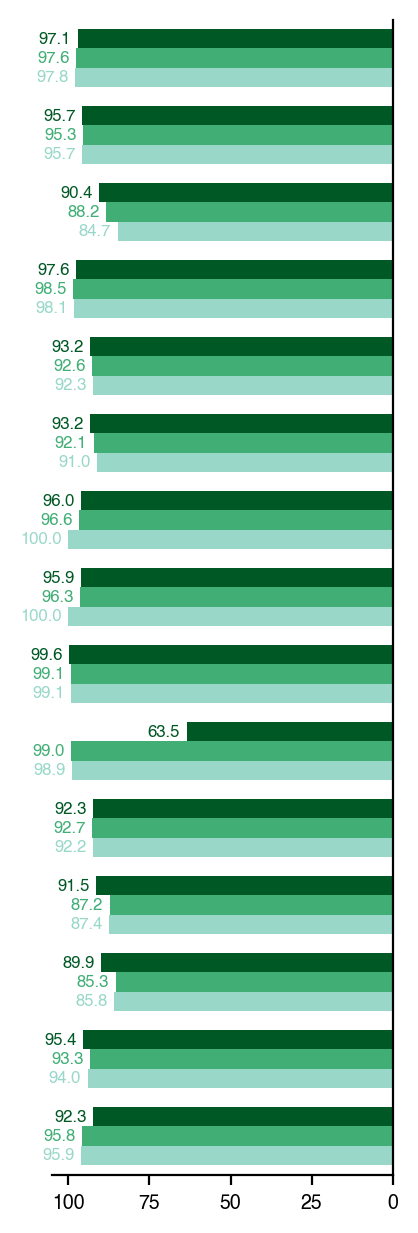

In [189]:
#training set (cryptic-v1.0.0)
graphs.plot_bar_catomatic(results_training, 'figs/performance/bar-training-who1-who2-cat1.pdf', who_drugs, show_graph=True)
graphs.plot_bar_catomatic_coverage(results_training, 'figs/performance/bar-training-who1-who2-cat1-coverage.pdf', who_drugs, show_graph=True)

### WHOv1 VS WHOv2 vs catomatic on training set (binary)

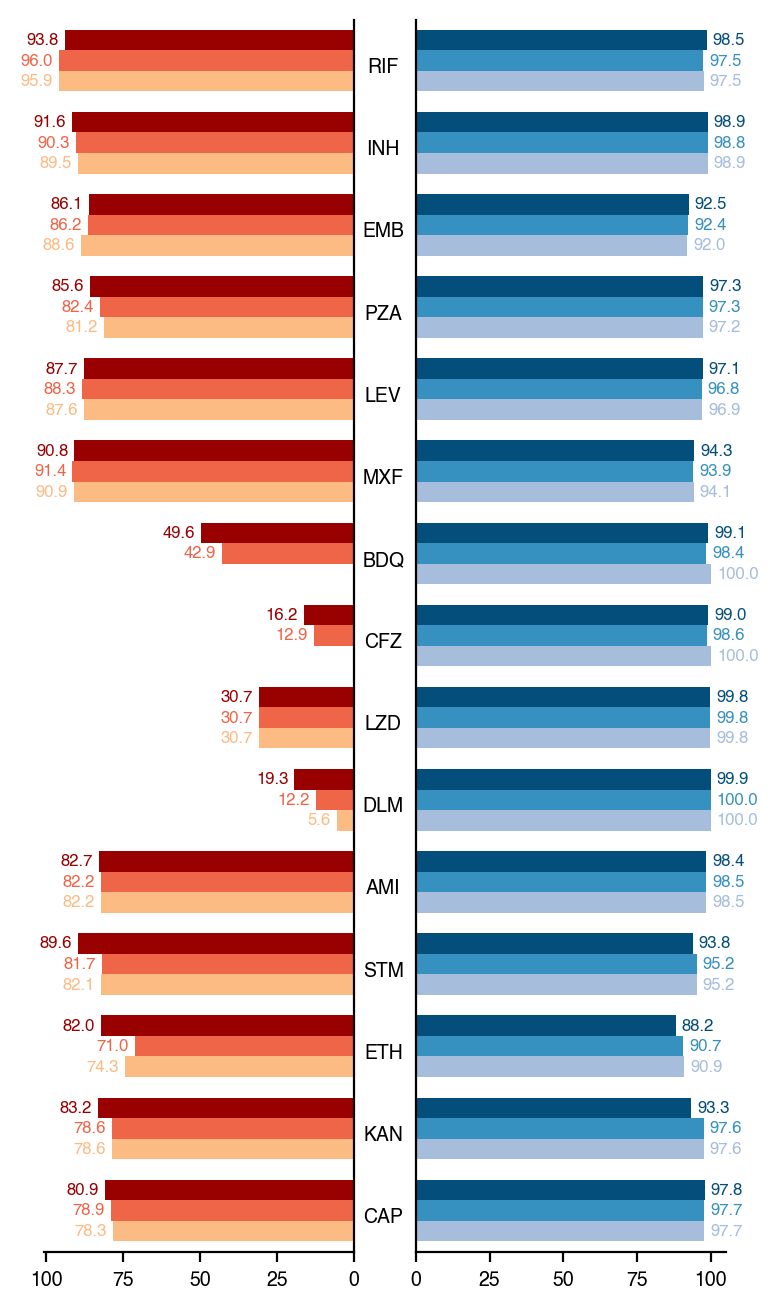

In [194]:
graphs.plot_bar_catomatic(results_training, 'figs/performance/bar-training-who1-who2-cat1-binary.pdf', who_drugs, show_graph=True,  sensitivity='SENSITIVITY2', specificity='SPECIFICITY2')

### WHOv1 VS WHOv2 vs catomatic on validation set (ternary)

In [191]:
results_validation = pd.read_csv('results/performance/whov1_whov2_cat1_validation.csv')
results_validation.DRUG = results_validation.DRUG.astype('category')
results_validation.DRUG = results_validation.DRUG.cat.set_categories(who_drugs)
results_validation.sort_values(['DRUG','catalogue'], inplace=True)
results_validation = results_validation.iloc[::-1]
results_validation = results_validation[results_validation.DRUG.isin(who_results.drug.values)]
results_validation[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
8,8,CAP,catomatic_v3.3.0,0.793478,0.980912,0.938904,0.736134,0.982055,438,114,5036,98,43,327
7,7,CAP,WHOv2,0.802768,0.980505,0.959379,0.779832,0.981322,464,114,5130,102,17,229
6,6,CAP,WHOv1,0.792727,0.981294,0.955911,0.732773,0.982055,436,114,5141,98,45,222
26,26,KAN,catomatic_v3.3.0,0.866599,0.928624,0.954467,0.856137,0.932208,851,131,6271,482,12,357
25,25,KAN,WHOv2,0.861366,0.981848,0.936821,0.850101,0.983122,845,136,6491,120,13,499
24,24,KAN,WHOv1,0.861366,0.981963,0.942004,0.850101,0.983122,845,136,6533,120,13,457


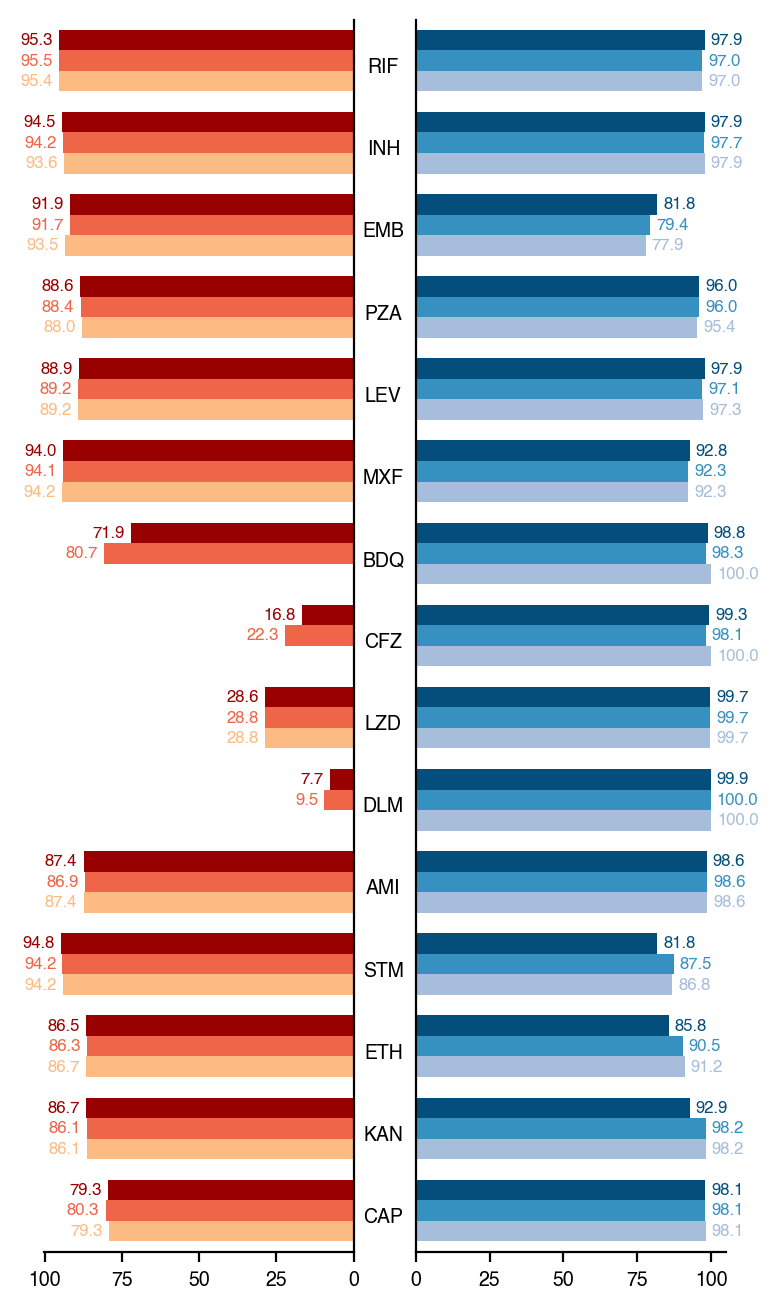

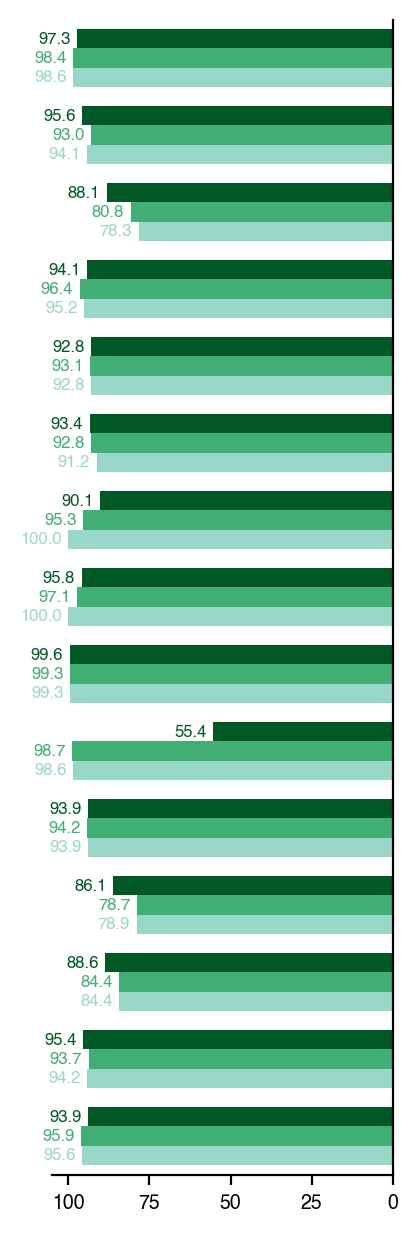

In [192]:
#training set (cryptic-v1.0.0)
graphs.plot_bar_catomatic(results_validation, 'figs/performance/bar-validation-who1-who2-cat1.pdf', who_drugs, show_graph=True)
graphs.plot_bar_catomatic_coverage(results_validation, 'figs/performance/bar-validation-who1-who2-cat1-coverage.pdf', who_drugs, show_graph=True)

### WHOv1 VS WHOv2 vs catomatic on training set (binary)

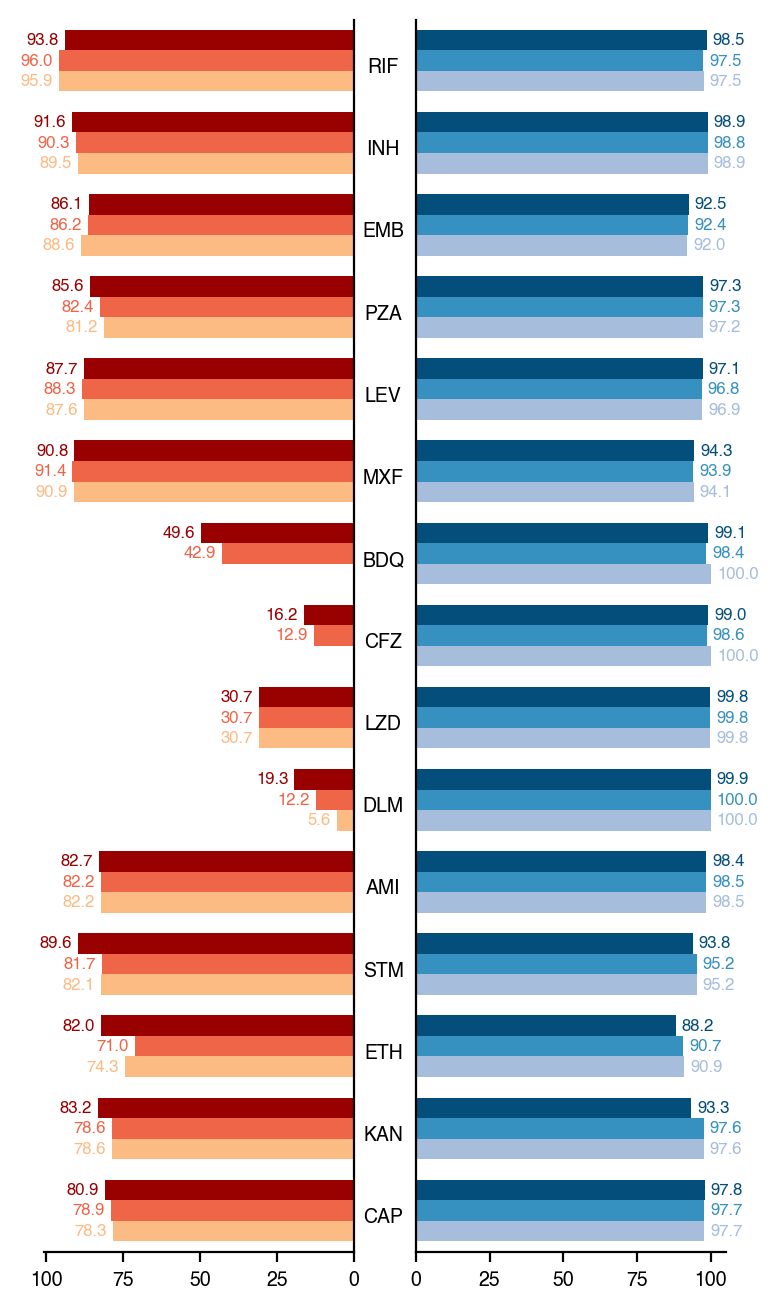

In [195]:
graphs.plot_bar_catomatic(results_training, 'figs/performance/bar-validation-who1-who2-cat1-binary.pdf', who_drugs, show_graph=True,  sensitivity='SENSITIVITY2', specificity='SPECIFICITY2')

### WHOv1 without rules vs WHOv1 with rules vs catomaticv1 (ternary)

In [202]:
results_val_no_rules = pd.read_csv('results/performance/whov1_no_rules_whov1_cat1_validation.csv')
results_val_no_rules.DRUG = results_val_no_rules.DRUG.astype('category')
results_val_no_rules.DRUG = results_val_no_rules.DRUG.cat.set_categories(who_drugs)
results_val_no_rules.sort_values(['DRUG','catalogue'], inplace=True, ascending=False)
results_val_no_rules = results_val_no_rules.iloc[::-1]
results_val_no_rules = results_val_no_rules[results_val_no_rules.DRUG.isin(who_results.drug.values)]
results_val_no_rules[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
22,22,INH,WHOv1,0.935785,0.978849,0.941002,0.892830,0.980332,4707,323,5646,122,242,435
21,21,INH,WHOv1_no_rules,0.934997,0.979698,0.935251,0.881259,0.981138,4646,323,5646,117,303,440
23,23,INH,catomatic_v3.3.0,0.944871,0.978785,0.956078,0.910281,0.979848,4799,280,5767,125,193,311
40,40,RIF,WHOv1,0.954291,0.970258,0.985667,0.951407,0.970883,4092,196,6916,212,13,153
39,39,RIF,WHOv1_no_rules,0.952817,0.978772,0.968745,0.920251,0.979398,3958,196,6916,150,147,215
41,41,RIF,catomatic_v3.3.0,0.952654,0.978561,0.973234,0.926296,0.979124,3984,198,6938,152,119,191


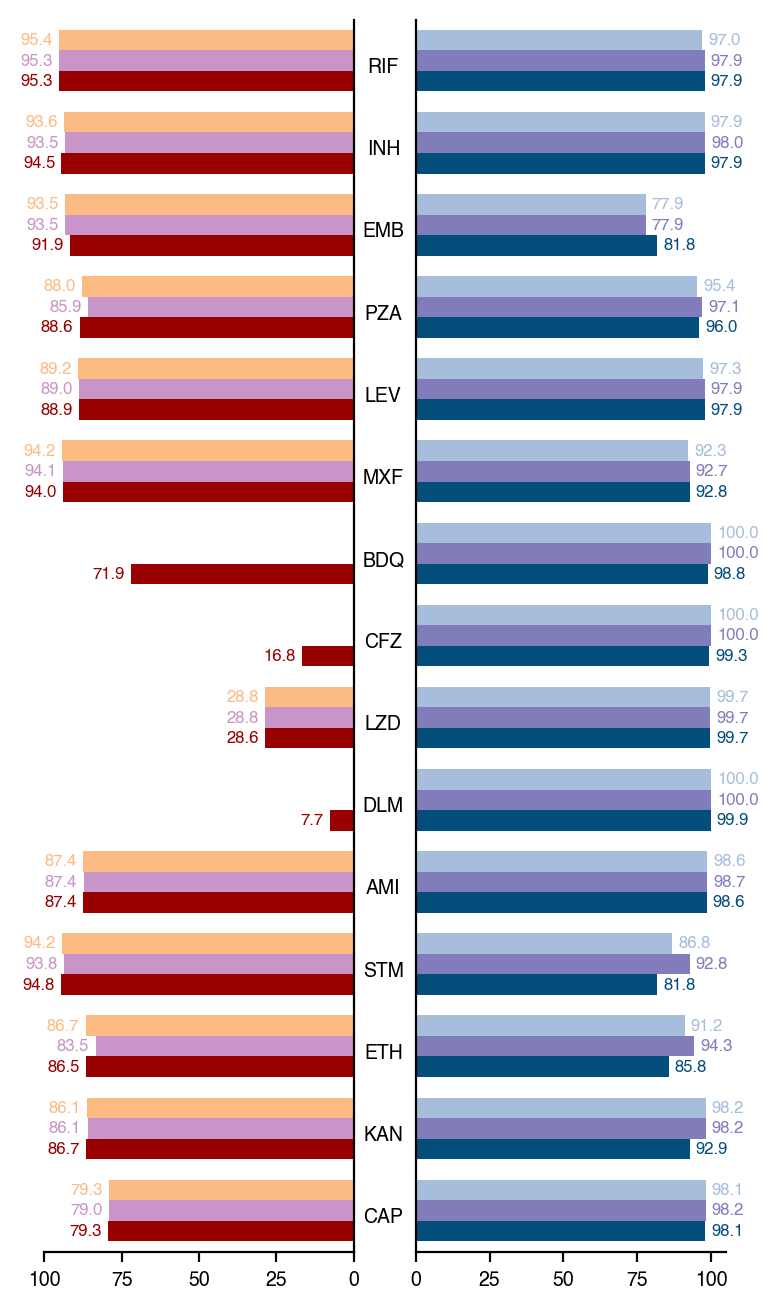

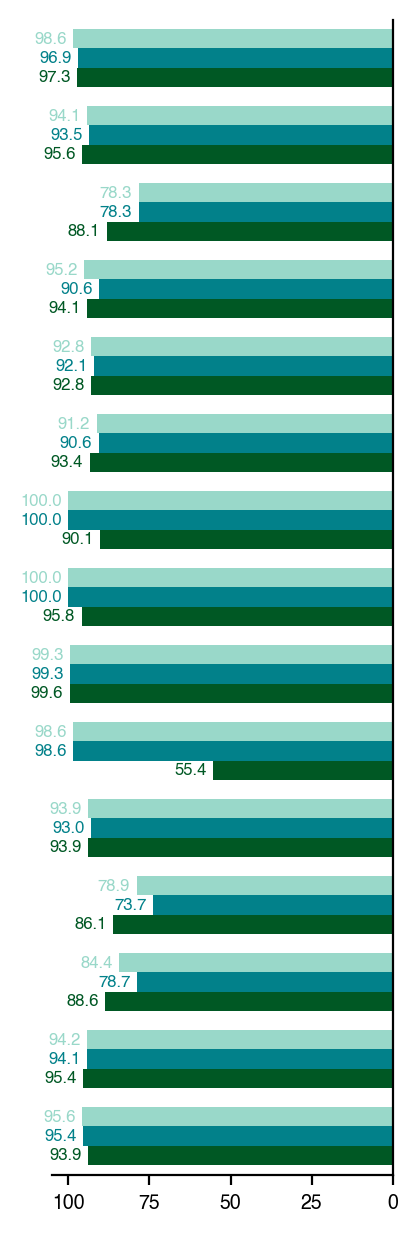

In [203]:
graphs.plot_bar_catomatic(results_val_no_rules, 'figs/performance/bar-validation-who1_no_rules-who1-cat1.pdf', who_drugs, show_graph=True)
graphs.plot_bar_catomatic_coverage(results_val_no_rules, 'figs/performance/bar-validation-who1_no_rules-who1-cat1-coverage.pdf', who_drugs, show_graph=True)

### catomatic trained on training set vs catomatic trained on all data, applied to all data


In [206]:
results_all_samples = pd.read_csv('results/performance/cat_all_samples.csv')
results_all_samples.DRUG = results_all_samples.DRUG.astype('category')
results_all_samples.DRUG = results_all_samples.DRUG.cat.set_categories(who_drugs)
results_all_samples.sort_values(['DRUG','catalogue'], inplace=True)
results_all_samples = results_all_samples.iloc[::-1]
results_all_samples[:6]

,Unnamed: 0,DRUG,catalogue,SENSITIVITY,SPECIFICITY,COVERAGE,SENSITIVITY2,SPECIFICITY2,TP,FN,TN,FP,UP,UN
5,5,CAP,catomatic_v3.3.0_all_samples,0.824950,0.977598,0.929635,0.793037,0.979243,1230,261,14532,333,60,1178
4,4,CAP,catomatic_v3.3.0,0.822690,0.977730,0.928442,0.780787,0.979368,1211,261,14532,331,79,1180
17,17,KAN,catomatic_v3.3.0_all_samples,0.825698,0.974336,0.962310,0.816059,0.975381,2307,487,22627,596,33,986
16,16,KAN,catomatic_v3.3.0,0.846455,0.929224,0.954098,0.840467,0.932794,2376,431,21361,1627,20,1221
13,13,ETH,catomatic_v3.3.0_all_samples,0.885992,0.897516,0.885830,0.743511,0.908067,2922,376,13154,1502,632,1682
12,12,ETH,catomatic_v3.3.0,0.896611,0.865694,0.895500,0.794402,0.879422,3122,360,12698,1970,448,1670


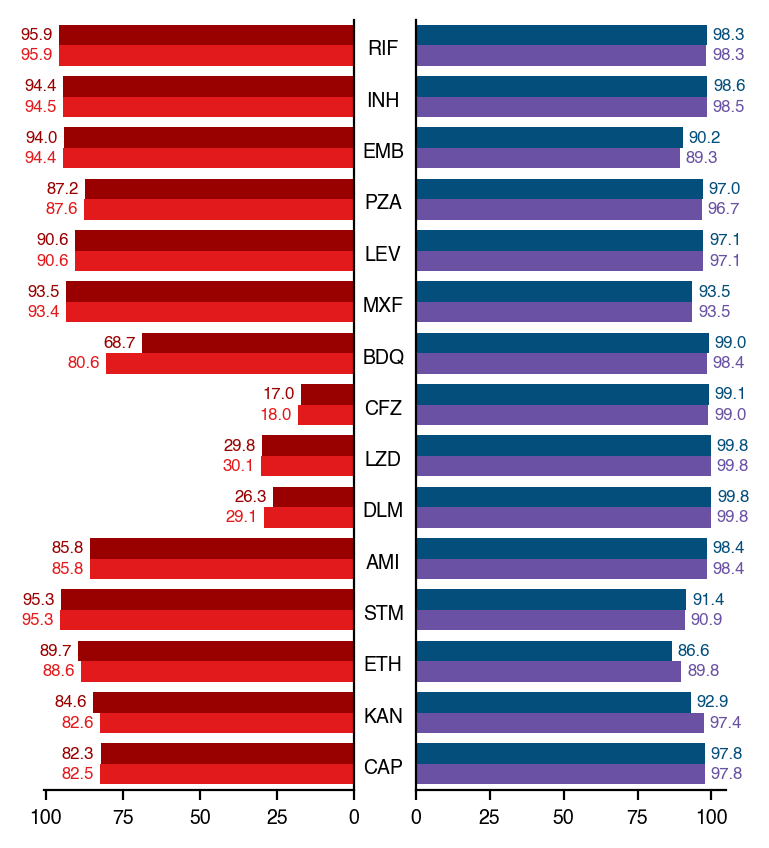

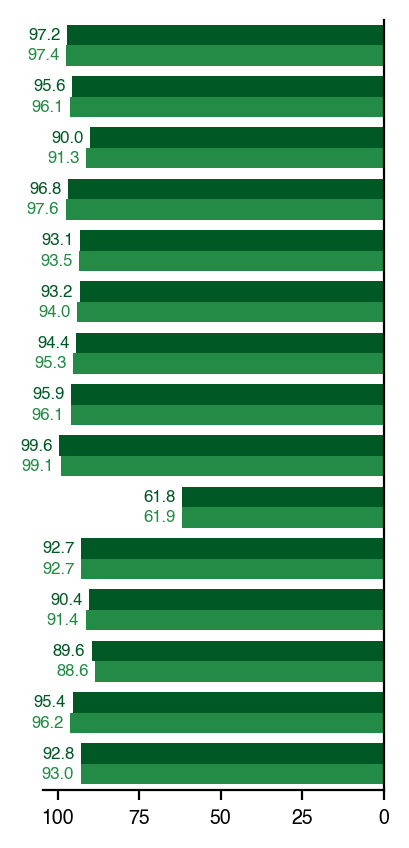

In [207]:
graphs.plot_bar_catomatic(results_all_samples, 'figs/performance/bar-all-samples-ternary.pdf', who_drugs, catalogues=['catomatic_v3.3.0', 'catomatic_v3.3.0_all_samples'],  figsize=(4.4, 5), barwidth=0.4, show_graph=True)
graphs.plot_bar_catomatic_coverage(results_all_samples, 'figs/performance/bar-all-samples-coverage.pdf', who_drugs, catalogues=['catomatic_v3.3.0', 'catomatic_v3.3.0_all_samples'], figsize=(2.2, 5), barwidth=0.4, show_graph=True)

## Further analysis

In [ ]:
train_phenotypes = functions.prep_phenotypes(
'EMB',
cryptic_tables_path+'DST_MEASUREMENTS.csv.gz',
cryptic_tables_path+'GENOMES.parquet',
cryptic_tables_path+'WGS_SAMPLES.parquet',
version='v3.3.0',
validation= False
).set_index('UNIQUEID', inplace=True)

val_phenotypes = functions.prep_phenotypes(
'EMB',
cryptic_tables_path+'DST_MEASUREMENTS.csv.gz',
cryptic_tables_path+'GENOMES.parquet',
cryptic_tables_path+'WGS_SAMPLES.parquet',
version='v3.3.0',
validation= True
).set_index('UNIQUEID', inplace=True)

mutations = functions.prep_mutations(
    'data/mutations-v3.3.0/', 
    ['embA', 'embB'], 
    version='v3.3.0', 
    mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
    var_path=cryptic_tables_path+'VARIANTS.parquet',
    train=False
).set_index('UNIQUEID', inplace=True)



In [ ]:
train_phenotypes.rename(columns={'METHOD_MIC':'MIC'}, inplace=True)
train_phenotypes = train_phenotypes.dropna(subset=['MIC'])
train_mutations = mutations[mutations.UNIQUEID.isin(train_phenotypes.UNIQUEID.unique())]

catalogue_obj = RegressionBuilder(train_phenotypes, train_mutations, censored=False, tail_dilutions=3, genes=['embA', 'embB'])
model, effects = catalogue_obj.predict_effects(options={'ftol':1e-6, 'gtol':1e-4}, random_effects=False, cluster_distance=100, L2_penalties={}, b_bounds=(None, None))

embB@M306I


/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/graphs.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  # Remove top and right spines


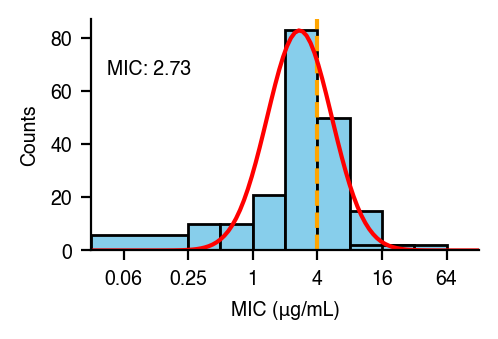

embB@M306V


/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/graphs.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  # Remove top and right spines


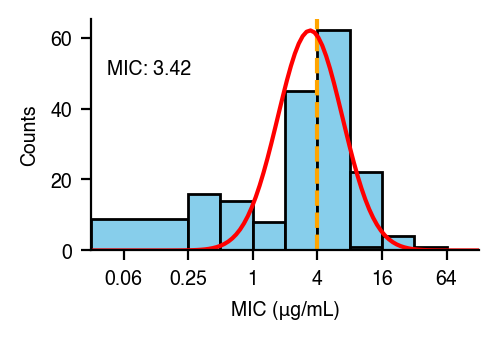

In [ ]:
df = catalogue_obj.df.copy()
y_low, y_high = catalogue_obj.define_intervals(df)
df['y_low_log'] = y_low
df['y_high_log'] = y_high

graphs.plot_fitted_distribution(effects[effects.Mutation.isin(['embB@M306I', 'embB@M306V'])], df, 2, 20, -5, 7)

In [ ]:
val_phenotypes.rename(columns={'METHOD_MIC':'MIC'}, inplace=True)
val_phenotypes = val_phenotypes.dropna(subset=['MIC'])
val_mutations = mutations[mutations.UNIQUEID.isin(val_phenotypes.UNIQUEID.unique())]

catalogue_obj = RegressionBuilder(val_phenotypes, val_mutations, censored=False, tail_dilutions=3, genes=['embA', 'embB'])
model, effects = catalogue_obj.predict_effects(options={'ftol':1e-6, 'gtol':1e-4}, random_effects=False, cluster_distance=100, L2_penalties={}, b_bounds=(None, None))

embB@M306I


/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/graphs.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  # Remove top and right spines


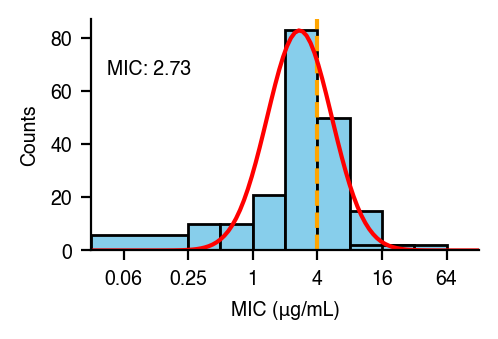

embB@M306V


/Users/dylanadlard/Documents/Oxford/PhD/Projects/cryptic-catalogues-2025/protocols/graphs.py:648: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  # Remove top and right spines


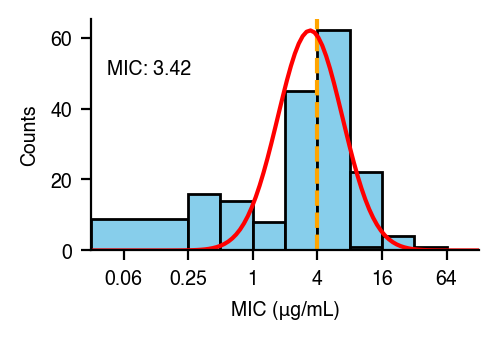

In [ ]:
df = catalogue_obj.df.copy()
y_low, y_high = catalogue_obj.define_intervals(df)
df['y_low_log'] = y_low
df['y_high_log'] = y_high

graphs.plot_fitted_distribution(effects[effects.Mutation.isin(['embB@M306I', 'embB@M306V'])], df, 2, 20, -5, 7)

In [ ]:
pd.read_parquet('data/cryptic-tables-v3.3.0/GENOMES.parquet').reset_index().LINEAGE.value_counts()